Wpływ hiperparametrów C, gamma w klasyfikatorze SVM
---------------------------------------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

Wczytanie zbioru danych

In [2]:
raw = load_breast_cancer()
X_df = pd.DataFrame(raw.data, columns=raw.feature_names)
y = raw.target

Wybór dwóch cech (z poprzedniego kroku, SHAP)

In [3]:
top2_names = np.array(['worst radius', 'mean radius'])
#top2_names = np.array(['worst area', 'worst concave points'])
X2 = X_df[top2_names].values

Podział na zbiory treningowe i testowe, standaryzacja danych

In [4]:
scaler = StandardScaler()
X2s = scaler.fit_transform(X2)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2s, y, stratify=y, test_size=0.25, random_state=0)

Funkcja wyswietlająca powierzchnię decyzyjną klasyfikatora SVM

In [5]:
def plot_svm(model, title=''):
    plt.figure(figsize=(5, 5))
    xx, yy = np.meshgrid(
        np.linspace(X2s[:, 0].min() - 1, X2s[:, 0].max() + 1, 500),
        np.linspace(X2s[:, 1].min() - 1, X2s[:, 1].max() + 1, 500),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    model.fit(X2_tr, y2_tr)
    Z = model.predict(grid).reshape(xx.shape)

    a_te = accuracy_score(y2_te, model.predict(X2_te))
    a_tr = accuracy_score(y2_tr, model.predict(X2_tr))
    info = f'Skutecznosc (z. treningowy) {a_tr:.2%} (z. testowy) {a_te:.2%}'


    plt.contourf(xx, yy, Z, cmap=ListedColormap(['r', 'b']), alpha=0.15)
    plt.scatter(*X2_tr[y2_tr == 0].T, c='r', s=100, edgecolor="k", 
               label="malignant", alpha=0.5)
    plt.scatter(*X2_tr[y2_tr == 1].T, c='b', s=100, edgecolor="k", 
               label="benign", alpha=0.5)

    plt.title(f"{title}\n{info}", fontsize=9)
    plt.xlabel(f'Cecha "{top2_names[0]}"')
    plt.ylabel(f'Cecha "{top2_names[1]}"')
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    plt.tight_layout()
    plt.show()

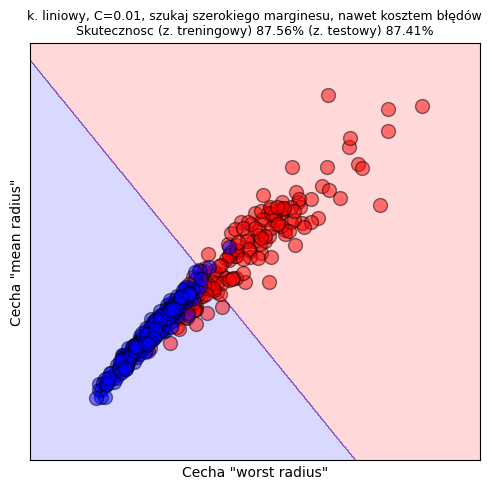

In [6]:
# underfit risk
plot_svm(SVC(kernel="linear", C=0.01), 
          "k. liniowy, C=0.01, szukaj szerokiego marginesu, nawet kosztem błędów")

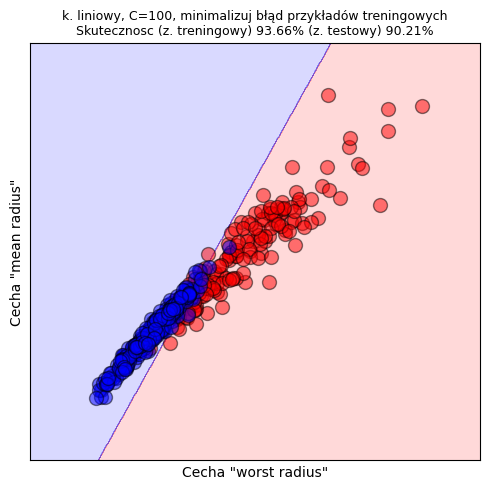

In [7]:
# overfit risk 
plot_svm(SVC(kernel="linear", C=100), 
          "k. liniowy, C=100, minimalizuj błąd przykładów treningowych")

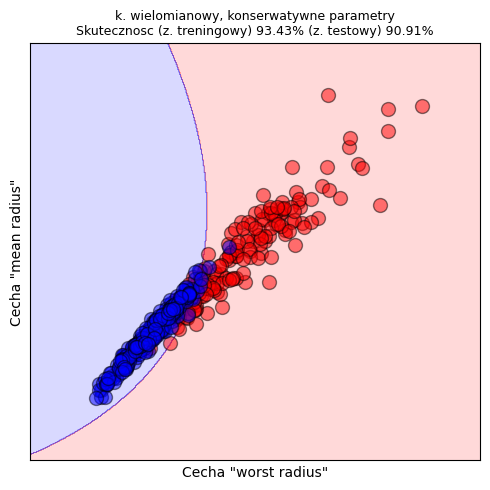

In [8]:
plot_svm(SVC(kernel="poly", degree=2, coef0=1, C=1), 
          "k. wielomianowy, konserwatywne parametry")

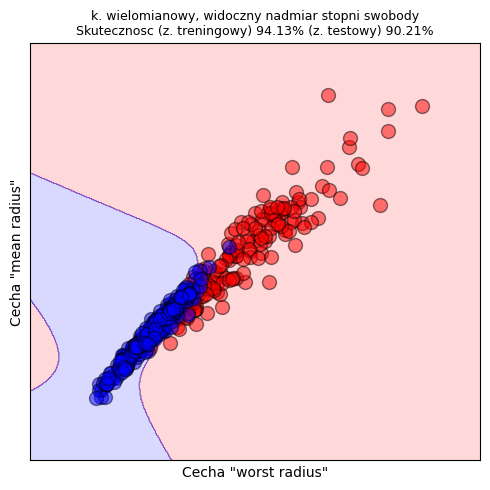

In [9]:
plot_svm(SVC(kernel="poly", degree=7, coef0=1, C=1), 
          "k. wielomianowy, widoczny nadmiar stopni swobody")

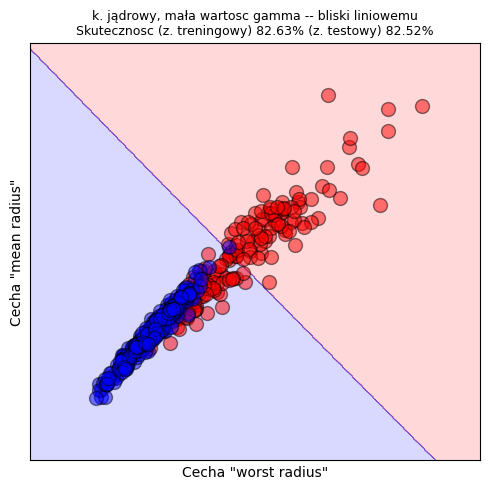

In [10]:
plot_svm(SVC(kernel="rbf", gamma=0.001, C=1), 
          "k. jądrowy, mała wartosc gamma -- bliski liniowemu")

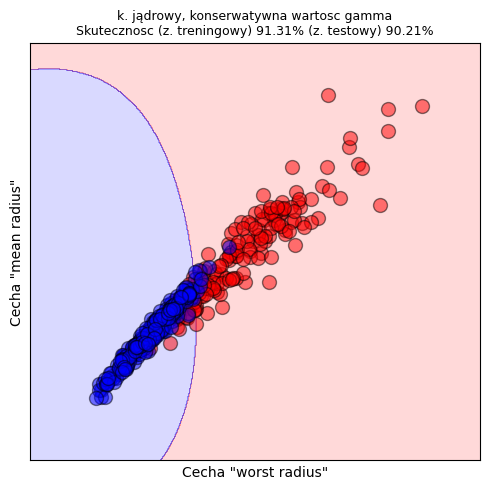

In [11]:
plot_svm(SVC(kernel="rbf", gamma=0.1, C=1), 
          "k. jądrowy, konserwatywna wartosc gamma")

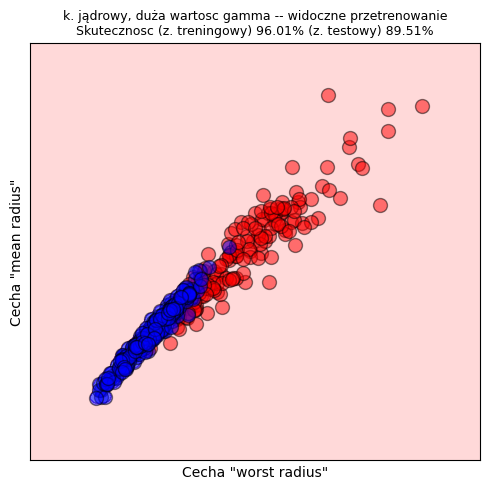

In [12]:
plot_svm(SVC(kernel="rbf", gamma=100, C=1), 
          "k. jądrowy, duża wartosc gamma -- widoczne przetrenowanie")

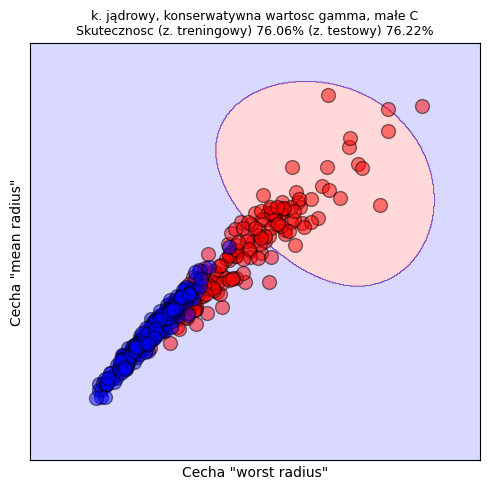

In [13]:
plot_svm(SVC(kernel="rbf", gamma=0.1, C=0.01), 
          "k. jądrowy, konserwatywna wartosc gamma, małe C")

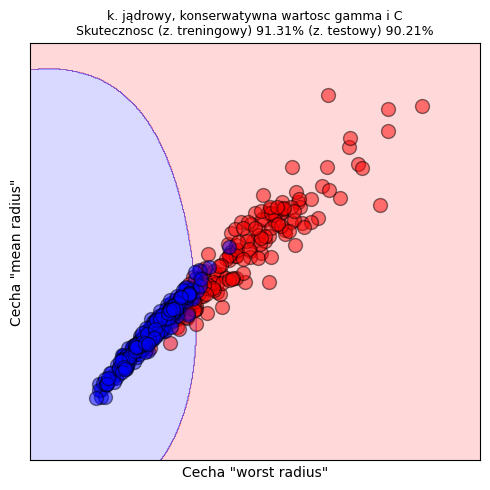

In [14]:
plot_svm(SVC(kernel="rbf", gamma=0.1, C=1), 
          "k. jądrowy, konserwatywna wartosc gamma i C")

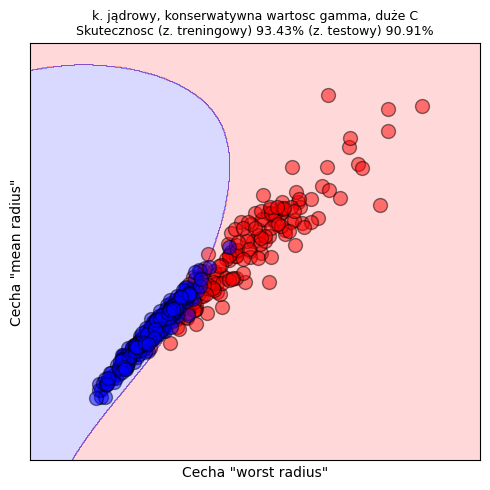

In [15]:
plot_svm(SVC(kernel="rbf", gamma=0.1, C=100), 
          "k. jądrowy, konserwatywna wartosc gamma, duże C")